# Comparaison des algos : DC avec PPR vs DC avec Ψ-score vs Louvain sur le  Dataset Brexit

Ce notebook compare **trois** algorithmes de détection de communautés (DC) sur le dataset **Brexit** :

| Algorithme | Matrice R | Description |
|---|---|---|
|DC **PPR** | `nx.pagerank` avec personnalisation (alpha=0.85) | Clustering hiérarchique agglomératif avec Personalized PageRank classique |
| DC **Ψ-score** | `PsiScore` (λ=μ=1 : cas homogène = PPR) | Même clustering mais la matrice R intègre les flux de posting/reposting |
| **Louvain** | — | Optimisation directe de la modularité (référence networkx) |

---

### Métriques comparées 

| Colonne | Métrique | Implémentation | Note |
|---|---|---|---|
| Groupes prédéfinis PPR | **NMI / ARI** vs opinions réelles | scikit-learn | Opinions = remain/leave/neutral |
| Clusters avec autre algo | **NMI/ARI croisé** | scikit-learn | L avec R_PPR avec Psi-score |
| Structure du graphe | **Modularité Q** (↑ mieux) | networkx | Séparation des groupes |
| Structure du graphe | **Conductance** (↓ mieux) | networkx | Inverse : à quel point les groupes sont rapprochés |

---

### Hypothèses

- **Modularité Q** : on s'attend à ce que Louvain > PPR ≈ Ψ-score, car Louvain maximise Q directement, tandis que PPR/Ψ utilisent uniquement la structure du graphe via la matrice de diffusion.
- **NMI** : on s'attend à ce que Ψ-score > PPR > Louvain, car Ψ-score modélise les flux de tweets/retweets et devrait mieux capturer les opinions politiques réelles.

## 1. Imports

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import scipy.sparse as sp
import pandas as pd
import time
from collections import Counter

# Métriques - scikit-learn
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Algorithmes
from networkx.algorithms.community import modularity as nx_modularity
from networkx.algorithms.community import louvain_communities

# Psi-score
# Si non installé : !pip install git+https://github.com/NouamaneA/psi-score.git --ignore-requires-python -q
from psi_score import PsiScore
import data as dt

print("Imports done")

Imports done


## 2. Chargement du dataset Brexit

In [2]:
bre = dt.BrexitFollowers(root="data/Brexit")
graph_directed = bre.to_networkx()   # DiGraph dirigé (tweets/retweets)
graph = graph_directed.to_undirected()

print(f"Graphe complet : {bre.n} nœuds, {bre.m} arêtes")
print(f"Opinions disponibles : {set(nx.get_node_attributes(graph, 'max_opinion').values())}")

Graphe complet : 7589 nœuds, 532459 arêtes
Opinions disponibles : {'leave', 'remain', 'neutral'}


## 3. Construction du sous-graphe (Top-K nœuds par degré)

In [3]:
K = 100   # Modifier : 50 (rapide), 100 (recommandé), 200 (lent)

top_nodes = sorted(graph.nodes(), key=lambda n: graph.degree(n), reverse=True)[:K]
subgraph = graph.subgraph(top_nodes).copy()

if not nx.is_connected(subgraph):
    largest_cc = max(nx.connected_components(subgraph), key=len)
    subgraph = subgraph.subgraph(largest_cc).copy()
    print(f"Sous-graphe non connexe -> plus grande composante : {subgraph.number_of_nodes()} nœuds")
else:
    print("Sous-graphe connexe ")

subgraph = nx.convert_node_labels_to_integers(subgraph, label_attribute="original_id")
N = subgraph.number_of_nodes()
A_sub = nx.to_scipy_sparse_array(subgraph, format='csr')
pos = nx.spring_layout(subgraph, seed=42)

# Labels réels (opinions)
opinion_str = [subgraph.nodes[n].get("max_opinion", "neutral") for n in subgraph.nodes()]
opinion_map = {"remain": 0, "leave": 1, "neutral": 2}
true_labels = np.array([opinion_map[o] for o in opinion_str])

cnt = Counter(opinion_str)
print(f"\nSous-graphe : {N} nœuds, {subgraph.number_of_edges()} arêtes")
print(f"Opinions : remain={cnt['remain']}  leave={cnt['leave']}  neutral={cnt['neutral']}")

palette = {"remain": "steelblue", "leave": "tomato", "neutral": "silver"}
node_colors_opinion = [palette[o] for o in opinion_str]

Sous-graphe connexe 

Sous-graphe : 100 nœuds, 1987 arêtes
Opinions : remain=31  leave=59  neutral=10


## 4. Fonctions utilitaires

In [30]:
# Clustering hiérarchique (partagé par PPR et Psi-score)

def community_opinion_vec(R, C):
    return R[list(C), :].mean(axis=0)

def delta_sigma(R, C1, C2, degrees):
    n = R.shape[0]
    p1 = community_opinion_vec(R, C1)
    p2 = community_opinion_vec(R, C2)
    diff = p1 - p2
    dist2 = (diff ** 2 / degrees).sum()
    weight = (len(C1) * len(C2)) / (len(C1) + len(C2))
    return (1 / n) * weight * dist2

def are_connected(A, C1, C2):
    sub = A[np.ix_(list(C1), list(C2))]
    return sub.nnz > 0 if sp.issparse(sub) else sub.any()

def hierarchical_clustering(A, G, R, verbose=False):
    """
    Clustering agglomératif guidé par delta_sigma.
    Retient la partition qui maximise la modularité Q.
    Commun aux algorithmes PPR et Ψ-score.
    """
    n = A.shape[0]
    degrees = np.array(A.sum(axis=1)).flatten()
    degrees[degrees == 0] = 1

    communities = [{i} for i in range(n)]
    best_partition, best_Q = communities.copy(), -np.inf
    history, step = [], 0

    while len(communities) > 1:
        best_ds, best_pair = np.inf, None
        for i in range(len(communities)):
            for j in range(i + 1, len(communities)):
                if not are_connected(A, communities[i], communities[j]):
                    continue
                ds = delta_sigma(R, communities[i], communities[j], degrees)
                if ds < best_ds:
                    best_ds, best_pair = ds, (i, j)
        if best_pair is None:
            break
        i, j = best_pair
        merged = communities[i] | communities[j]
        communities = [c for k, c in enumerate(communities) if k not in (i, j)]
        communities.append(merged)
        Q = nx_modularity(G, communities)
        history.append((step, len(communities), Q))
        if Q > best_Q:
            best_Q, best_partition = Q, [c.copy() for c in communities]
        if verbose and step % 10 == 0:
            print(f"  step {step:3d} | {len(communities):3d} comm. | Q={Q:.4f}")
        step += 1

    if verbose:
        print(f" {step} fusions | meilleure Q={best_Q:.4f} -> {len(best_partition)} communautés")
    return best_partition, history


# Conversion partition : labels

def to_labels(communities, N):
    labels = np.zeros(N, dtype=int)
    for idx, c in enumerate(communities):
        for node in c:
            labels[node] = idx
    return labels


# NMI-Pureté est dans [-0.5, 1] 
# Motivation : NMI seule != 1 même avec clusters parfaits si labels neutres
# sont dispersés. La Pureté penalise la dispersion -> combinaison plus juste
# Test Formule : NMI_purity = NMI + Purity - 1 (à voir si c'est pertinant de la laisser)


def purity(true_labels, pred_labels):
    """Pureté = fraction de nœuds dans le label majoritaire de leur cluster."""
    total = 0
    for c in np.unique(pred_labels):
        mask = pred_labels == c
        total += Counter(true_labels[mask]).most_common(1)[0][1]
    return total / len(true_labels)

def nmi_purity(true_labels, pred_labels):
    """
    NMI-Pureté ∈ [-0.5, 1].
    Corrige le biais de NMI face aux labels neutres (opinions non polarisées).
    """
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    pur = purity(true_labels, pred_labels)
    return nmi + pur - 1.0


# Conductance
# Conductance(S) = arêtes_coupées / min(vol(S), vol(V\S))
# bas = communauté bien isolée (peu d'arêtes vers l'extérieur vs degré interne)
# Inverse de la modularité : Q haute (à peu près égal à la) conductance faible (mais pas identiques)

def conductance(G, community):
    S = set(community)
    cut = nx.cut_size(G, S)
    vol_S  = sum(d for _, d in G.degree(S))
    vol_cS = sum(d for _, d in G.degree(set(G.nodes()) - S))
    denom = min(vol_S, vol_cS)
    return cut / denom if denom > 0 else 0.0

def mean_conductance(G, communities):
    """Conductance moyenne pondérée par la taille"""
    total_n = sum(len(c) for c in communities)
    return sum(conductance(G, c) * len(c) / total_n for c in communities if len(c) > 0)


# Calcul complet des métriques

def evaluate(algo_name, G, communities, true_labels, other_partitions=None):
    """
    Calcule toutes les métriques du tableau pour une partition donnée.
    other_partitions : dict {nom: labels} pour les comparaisons croisées
    """
    n = G.number_of_nodes()
    pred = to_labels(list(communities), n)

    # Structure du graphe
    Q    = nx_modularity(G, list(communities))
    cond = mean_conductance(G, list(communities))

    # vs opinions réelles
    nmi  = normalized_mutual_info_score(true_labels, pred)
    ari  = adjusted_rand_score(true_labels, pred)
    nmi_pur = nmi_purity(true_labels, pred)
    pur  = purity(true_labels, pred)

    result = {
        "Algo": algo_name,
        "Nb communautés": len(list(communities)),
        # Groupes prédéfinis
        "NMI (vs opinions)": round(nmi, 4),
        "ARI (vs opinions)": round(ari, 4),
        # Étiquettes / opinions
        "Pureté": round(pur, 4),
        "NMI-Pureté ∈[-0.5,1]": round(nmi_pur, 4),
        # Structure
        "Modularité Q haute": round(Q, 4),
        "Conductance faible": round(cond, 4),
    }

    # NMI/ARI croisés
    if other_partitions:
        for other_name, other_pred in other_partitions.items():
            result[f"NMI vs {other_name}"] = round(
                normalized_mutual_info_score(pred, other_pred), 4)
            result[f"ARI vs {other_name}"] = round(
                adjusted_rand_score(pred, other_pred), 4)

    result["_labels"] = pred
    return result

print("Fonctions chargées")

Fonctions chargées


## 5. Algorithme PPR

La matrice R est calculée via `nx.pagerank` avec personnalisation (vecteur unité sur le nœud source).
α = 0.85 (probabilité de damping), équivalent à une restart probability de 0.15.

In [5]:
def compute_ppr_matrix(G, alpha=0.85):
    """
    Matrice PPR n×n : R[i,j] = score PageRank du nœud j
    quand la seed est fixée sur le nœud i.
    """
    nodes = list(G.nodes())
    n = len(nodes)
    R = np.zeros((n, n))
    for i, src in enumerate(nodes):
        personalization = {v: (1.0 if v == src else 0.0) for v in nodes}
        ppr_i = nx.pagerank(G, alpha=alpha, personalization=personalization)
        R[i] = [ppr_i[v] for v in nodes]
    return R

print(f"Calcul de la matrice PPR sur {N} nœuds (nx.pagerank, alpha=0.85)...")
t0 = time.time()
R_ppr = compute_ppr_matrix(subgraph)
t_ppr_matrix = time.time() - t0
print(f"Matrice PPR : shape={R_ppr.shape} - calculée en {t_ppr_matrix:.1f}s")

Calcul de la matrice PPR sur 100 nœuds (nx.pagerank, alpha=0.85)...
Matrice PPR : shape=(100, 100) - calculée en 1.2s


In [6]:
print("Clustering PPR")
t0 = time.time()
communities_ppr, history_ppr = hierarchical_clustering(A_sub, subgraph, R_ppr, verbose=True)
t_ppr = time.time() - t0 + t_ppr_matrix
print(f"Temps total PPR : {t_ppr:.1f}s")

Clustering PPR
  step   0 |  99 comm. | Q=-0.0114
  step  10 |  89 comm. | Q=-0.0102
  step  20 |  79 comm. | Q=0.0009
  step  30 |  69 comm. | Q=0.0178
  step  40 |  59 comm. | Q=0.0452
  step  50 |  49 comm. | Q=0.0795
  step  60 |  39 comm. | Q=0.1165
  step  70 |  29 comm. | Q=0.1371
  step  80 |  19 comm. | Q=0.1606
  step  90 |   9 comm. | Q=0.1908
 99 fusions | meilleure Q=0.2545 -> 2 communautés
Temps total PPR : 68.5s


## 6. Algorithme Ψ-score

La matrice R est calculée via `PsiScore`  
Avec λ = μ = 1 pour tous les nœuds (cas homogène), le Ψ-score coïncide avec PPR (Theorem 5 de l'article).  
L'intérêt est que λ/μ peuvent capturer les taux de posting/reposting réels des tweets.

In [7]:
print(f"Calcul de la matrice Psi-score sur {N} nœuds (PsiScore, lambda=mu=1)...")
nodes = list(subgraph.nodes())
adjacency = {v: list(subgraph.neighbors(v)) for v in nodes}

t0 = time.time()
psiscore = PsiScore(solver='power_nf', max_iter=500, tol=1e-4)
psiscore.fit(adjacency, lambdas=[1.0]*N, mus=[1.0]*N, qs=nodes)
R_psi = np.array([psiscore.Q[i] for i in nodes])
t_psi_matrix = time.time() - t0
print(f"Matrice Psi : shape={R_psi.shape} — calculée en {t_psi_matrix:.1f}s")

100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:000:00


Calcul de la matrice Psi-score sur 100 nœuds (PsiScore, lambda=mu=1)...
Matrice Psi : shape=(100, 100) — calculée en 0.2s


In [8]:
print("Clustering Psi-score")
t0 = time.time()
communities_psi, history_psi = hierarchical_clustering(A_sub, subgraph, R_psi, verbose=True)
t_psi = time.time() - t0 + t_psi_matrix
print(f"Temps total Psi-score : {t_psi:.1f}s")

Clustering Psi-score
  step   0 |  99 comm. | Q=-0.0114
  step  10 |  89 comm. | Q=-0.0102
  step  20 |  79 comm. | Q=0.0009
  step  30 |  69 comm. | Q=0.0206
  step  40 |  59 comm. | Q=0.0553
  step  50 |  49 comm. | Q=0.0775
  step  60 |  39 comm. | Q=0.1091
  step  70 |  29 comm. | Q=0.1291
  step  80 |  19 comm. | Q=0.1597
  step  90 |   9 comm. | Q=0.2081
 99 fusions | meilleure Q=0.2391 -> 3 communautés
Temps total Psi-score : 67.9s


## 7. Algorithme Louvain

Louvain (Blondel et al., 2008) optimise directement la modularité Q par déplacements gloutons.  
Complexité quasi-linéaire → très rapide, mais aveugle aux opinions/labels.

In [10]:
print("Clustering Louvain")
t0 = time.time()
communities_louvain = list(louvain_communities(subgraph, seed=42))
t_louvain = time.time() - t0
print(f"Louvain : {len(communities_louvain)} communautés en {t_louvain:.2f}s")

Clustering Louvain
Louvain : 2 communautés en 0.05s


## 8. Évaluation complète — Tableau du cours

In [11]:
# Labels de chaque partition
lbl_ppr     = to_labels(communities_ppr, N)
lbl_psi     = to_labels(communities_psi, N)
lbl_louvain = to_labels(communities_louvain, N)

# Évaluation avec comparaisons croisées
res_ppr = evaluate("PPR",     subgraph, communities_ppr,
                   true_labels, {"Psi-score": lbl_psi, "Louvain": lbl_louvain})

res_psi = evaluate("Ψ-score", subgraph, communities_psi,
                   true_labels, {"PPR": lbl_ppr, "Louvain": lbl_louvain})

res_lou = evaluate("Louvain", subgraph, communities_louvain,
                   true_labels, {"PPR": lbl_ppr, "Psi-score": lbl_psi})

# Ajout des temps
res_ppr["Temps (s)"] = round(t_ppr, 1)
res_psi["Temps (s)"] = round(t_psi, 1)
res_lou["Temps (s)"] = round(t_louvain, 2)

# Tableau synthétique
cols_display = [
    "Algo", "Nb communautés",
    "NMI (vs opinions)", "ARI (vs opinions)",
    "Pureté", "NMI-Pureté ∈[-0.5,1]",
    "Modularité Q haute", "Conductance faible",
    "Temps (s)"
]
df_main = pd.DataFrame([res_ppr, res_psi, res_lou])[cols_display].set_index("Algo")
print("=" * 80)
print("TABLEAU COMPARATIF PRINCIPAL")
print("=" * 80)
print(df_main.to_string())

# Tableau croisé
cols_cross = [
    "Algo",
    "NMI vs Psi-score", "ARI vs Psi-score",
    "NMI vs Louvain", "ARI vs Louvain",
]
df_cross_ppr = pd.DataFrame([res_ppr])[cols_cross]

cols_cross2 = ["Algo", "NMI vs PPR", "ARI vs PPR", "NMI vs Louvain", "ARI vs Louvain"]
df_cross_psi = pd.DataFrame([res_psi])[cols_cross2]

cols_cross3 = ["Algo", "NMI vs PPR", "ARI vs PPR", "NMI vs Psi-score", "ARI vs Psi-score"]
df_cross_lou = pd.DataFrame([res_lou])[cols_cross3]

print("=" * 80)
print("COMPARAISONS CROISÉES (clusters vs autre algo - colonnes L, R_PPR du tableau)")
print("=" * 80)
print(df_cross_ppr.to_string(index=False))
print(df_cross_psi.to_string(index=False))
print(df_cross_lou.to_string(index=False))

TABLEAU COMPARATIF PRINCIPAL
         Nb communautés  NMI (vs opinions)  ARI (vs opinions)  Pureté  NMI-Pureté ∈[-0.5,1]  Modularité Q haute  Conductance faible  Temps (s)
Algo                                                                                                                                          
PPR                   2             0.3276             0.4508    0.79                0.1176              0.2545              0.1939      68.50
Ψ-score               3             0.3660             0.4880    0.81                0.1760              0.2391              0.2150      67.90
Louvain               2             0.3276             0.4508    0.79                0.1176              0.2545              0.1939       0.05
COMPARAISONS CROISÉES (clusters vs autre algo - colonnes L, R_PPR du tableau)
Algo  NMI vs Psi-score  ARI vs Psi-score  NMI vs Louvain  ARI vs Louvain
 PPR             0.894             0.946             1.0             1.0
   Algo  NMI vs PPR  ARI vs PPR 

In [29]:
df_main.style \
    .background_gradient(cmap='RdYlGn', subset=["NMI (vs opinions)", "ARI (vs opinions)",
                                                 "Pureté", "NMI-Pureté ∈[-0.5,1]",
                                                 "Modularité Q haute"]) \
    .background_gradient(cmap='RdYlGn_r', subset=["Conductance faible"]) \
    .set_caption(f"Comparaison PPR / Psi-score / Louvain - Brexit Top-{K} nœuds")

,Nb communautés,NMI (vs opinions),ARI (vs opinions),Pureté,"NMI-Pureté ∈[-0.5,1]",Modularité Q haute,Conductance faible,Temps (s)
Algo,,,,,,,,
PPR,2,0.327600,0.450800,0.790000,0.117600,0.254500,0.193900,68.500000
Ψ-score,3,0.366000,0.488000,0.810000,0.176000,0.239100,0.215000,67.900000
Louvain,2,0.327600,0.450800,0.790000,0.117600,0.254500,0.193900,0.050000


## 9. Visualisations

### 9.1 Graphe : opinions réelles vs 3 partitions

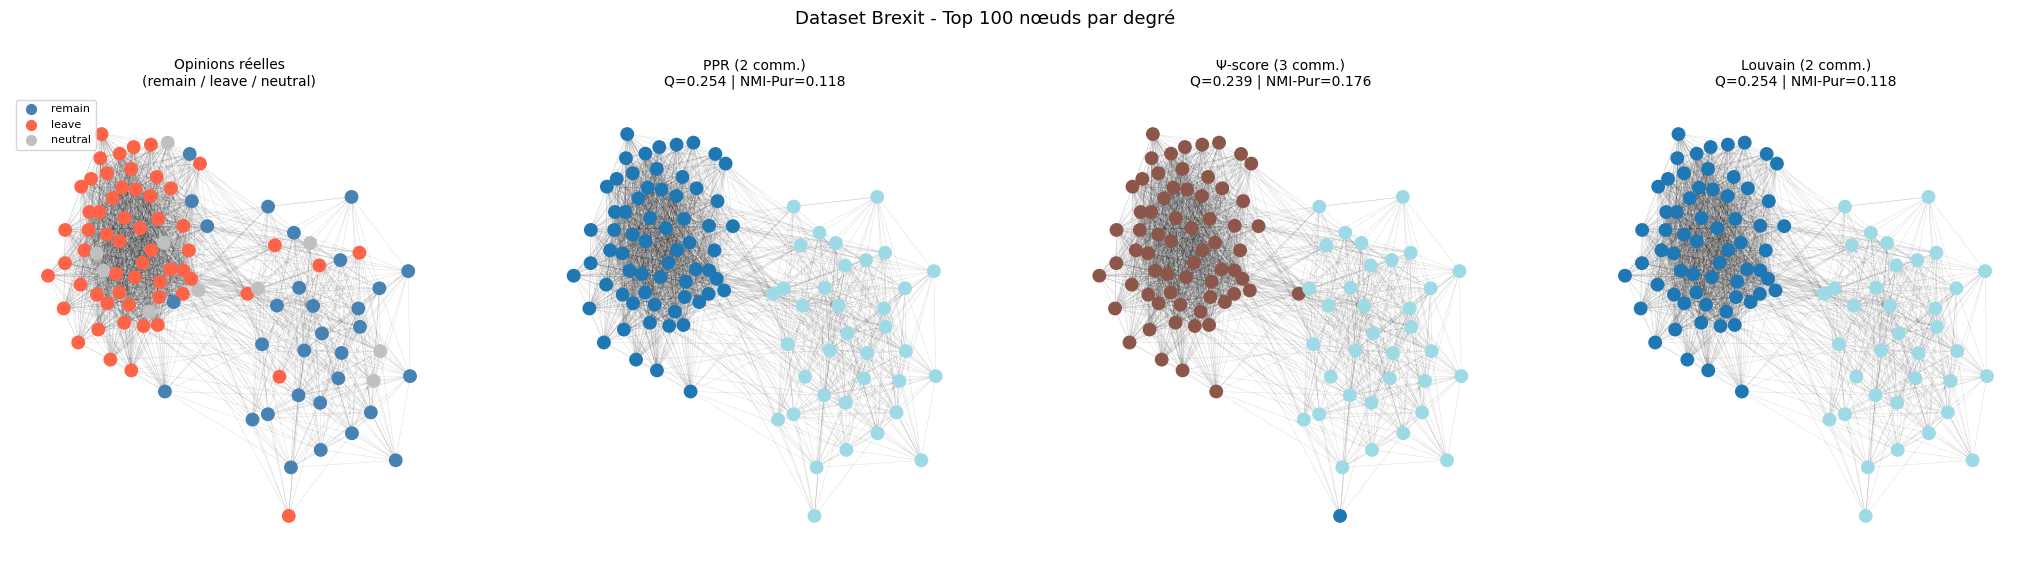

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(26, 6))

draw_kwargs = dict(pos=pos, alpha=0.12, width=0.4)

def draw_partition(ax, title, colors, cmap=None):
    nx.draw_networkx_edges(subgraph, ax=ax, **draw_kwargs)
    if cmap:
        nx.draw_networkx_nodes(subgraph, pos=pos, ax=ax,
                               node_color=colors, cmap=cmap, node_size=80)
    else:
        nx.draw_networkx_nodes(subgraph, pos=pos, ax=ax,
                               node_color=colors, node_size=80)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

# Opinions réelles
draw_partition(axes[0], "Opinions réelles\n(remain / leave / neutral)", node_colors_opinion)
for label, color in palette.items():
    axes[0].scatter([], [], c=color, label=label, s=50)
axes[0].legend(fontsize=8, loc="upper left")

# PPR
Q_ppr = nx_modularity(subgraph, communities_ppr)
draw_partition(axes[1],
    f"PPR ({len(communities_ppr)} comm.)\nQ={Q_ppr:.3f} | NMI-Pur={res_ppr['NMI-Pureté ∈[-0.5,1]']:.3f}",
    lbl_ppr, cmap=plt.cm.tab20)

# Psi-score
Q_psi = nx_modularity(subgraph, communities_psi)
draw_partition(axes[2],
    f"Ψ-score ({len(communities_psi)} comm.)\nQ={Q_psi:.3f} | NMI-Pur={res_psi['NMI-Pureté ∈[-0.5,1]']:.3f}",
    lbl_psi, cmap=plt.cm.tab20)

# Louvain
Q_lou = nx_modularity(subgraph, communities_louvain)
draw_partition(axes[3],
    f"Louvain ({len(communities_louvain)} comm.)\nQ={Q_lou:.3f} | NMI-Pur={res_lou['NMI-Pureté ∈[-0.5,1]']:.3f}",
    lbl_louvain, cmap=plt.cm.tab20)

plt.suptitle(f"Dataset Brexit - Top {K} nœuds par degré", fontsize=13, y=1.02)
plt.show()

### 9.2 HeatMap - Vue d'ensemble des métriques

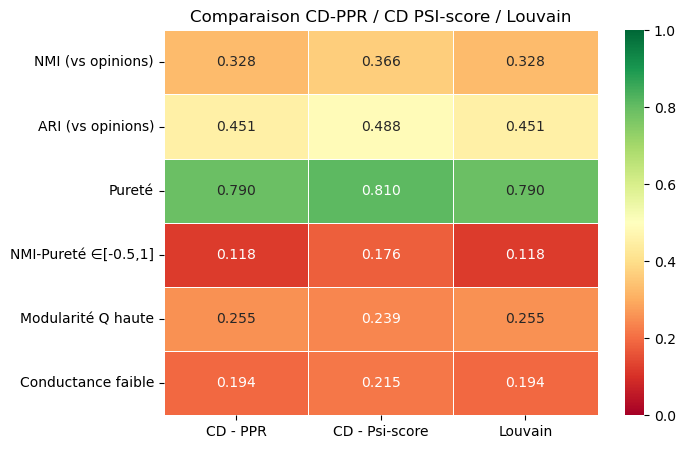

In [34]:
import seaborn as sns

metrics_radar = [
    ("NMI (vs opinions)",       "NMI"),
    ("ARI (vs opinions)",       "ARI"),
    ("Pureté",                  "Pureté"),
    ("NMI-Pureté ∈[-0.5,1]",   "NMI-Pureté"),
    ("Modularité Q haute",      "Modularité Q"),
    ("Conductance faible",      "Conductance"),
]

data_heat = pd.DataFrame({
    "CD - PPR":     [res_ppr[c] for c, _ in metrics_radar],
    "CD - Psi-score": [res_psi[c] for c, _ in metrics_radar],
    "Louvain": [res_lou[c] for c, _ in metrics_radar],
}, index=[c for c, _ in metrics_radar])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(data_heat, annot=True, fmt=".3f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Comparaison CD-PPR / CD PSI-score / Louvain")
plt.show()

### 9.3 Distribution des opinions par communauté (PPR / Ψ-score / Louvain)

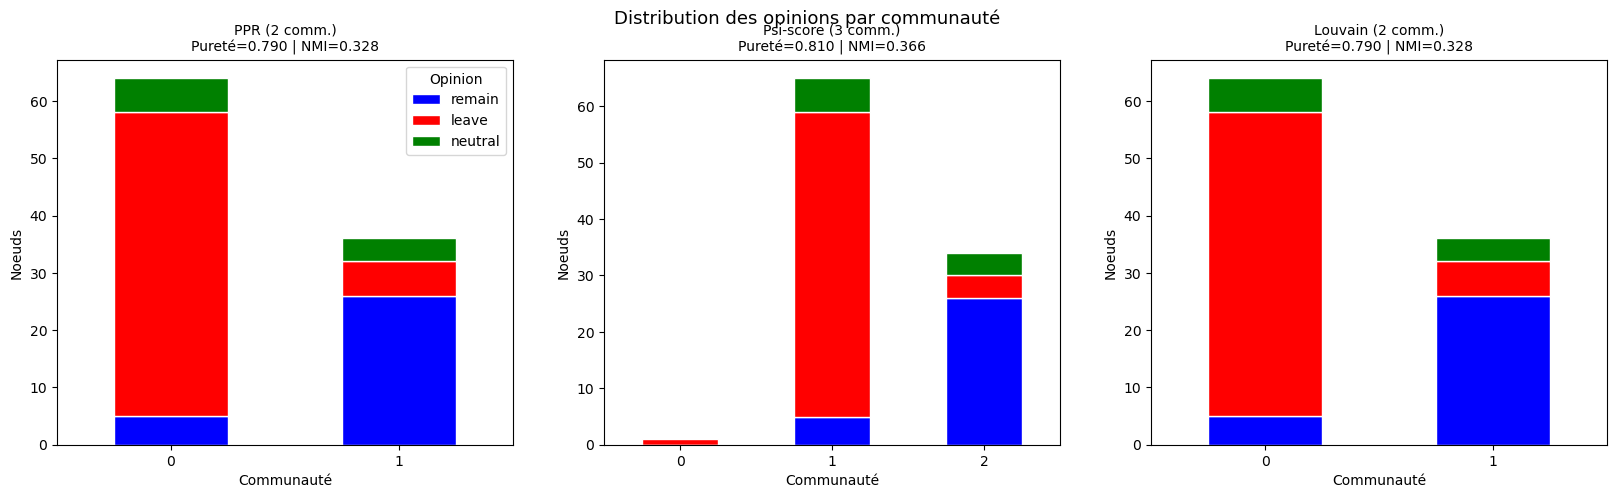

In [36]:
def opinion_df(communities, subgraph):
    rows = []
    for idx, c in enumerate(communities):
        ops = [subgraph.nodes[n].get("max_opinion", "neutral") for n in c]
        cnt = Counter(ops)
        rows.append({"Comm.": idx, "Taille": len(c),
                     "remain": cnt.get("remain", 0),
                     "leave":  cnt.get("leave",  0),
                     "neutral":cnt.get("neutral",0),
                     "Dominant": max(cnt, key=cnt.get) if cnt else "?"})
    return pd.DataFrame(rows).set_index("Comm.")

df_op_ppr = opinion_df(communities_ppr, subgraph)
df_op_psi = opinion_df(communities_psi, subgraph)
df_op_lou = opinion_df(communities_louvain, subgraph)

colors_bar = ["blue", "red", "green"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, df, title, res in zip(
    axes,
    [df_op_ppr, df_op_psi, df_op_lou],
    [f"PPR ({len(communities_ppr)} comm.)",
     f"Psi-score ({len(communities_psi)} comm.)",
     f"Louvain ({len(communities_louvain)} comm.)"],
    [res_ppr, res_psi, res_lou]
):
    df[["remain", "leave", "neutral"]].plot(
        kind="bar", stacked=True, ax=ax,
        color=colors_bar, edgecolor="white", legend=False
    )
    ax.set_title(f"{title}\nPureté={res['Pureté']:.3f} | NMI={res['NMI (vs opinions)']:.3f}",
                 fontsize=10)
    ax.set_xlabel("Communauté")
    ax.set_ylabel("Noeuds")
    ax.tick_params(axis='x', rotation=0)

axes[0].legend(["remain", "leave", "neutral"], title="Opinion", loc="upper right")
plt.suptitle("Distribution des opinions par communauté", fontsize=13)
plt.show()

### 9.4 Évolution de la modularité au fil des fusions (PPR vs Ψ-score)

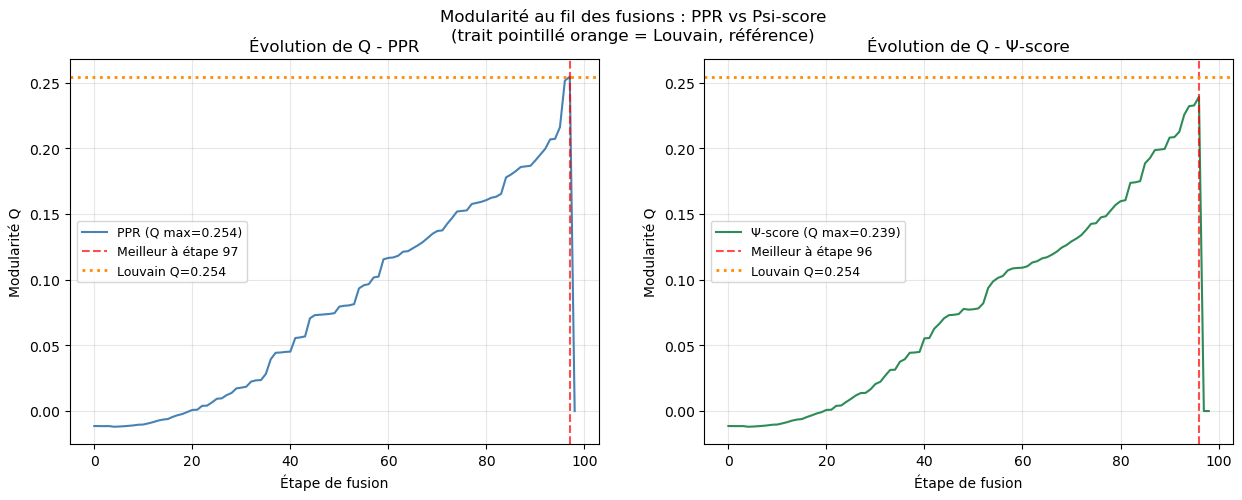

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

Q_louvain_val = nx_modularity(subgraph, communities_louvain)

for ax, history, label, color in zip(
    axes,
    [history_ppr, history_psi],
    ["PPR", "Ψ-score"],
    ["steelblue", "seagreen"]
):
    steps, n_comms, Q_vals = zip(*history)
    best_step = steps[np.argmax(Q_vals)]
    best_Q    = max(Q_vals)

    ax.plot(steps, Q_vals, color=color, linewidth=1.5, label=f"{label} (Q max={best_Q:.3f})")
    ax.axvline(best_step, color="red", linestyle="--", alpha=0.7, label=f"Meilleur à étape {best_step}")
    ax.axhline(Q_louvain_val, color="darkorange", linestyle=":", linewidth=2,
               label=f"Louvain Q={Q_louvain_val:.3f}")
    ax.set_xlabel("Étape de fusion")
    ax.set_ylabel("Modularité Q")
    ax.set_title(f"Évolution de Q - {label}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Modularité au fil des fusions : PPR vs Psi-score\n"
             "(trait pointillé orange = Louvain, référence)", fontsize=12)
plt.show()

### 9.5 Purété en fonction de la conductance par communauté (comparaison des 3 algos)

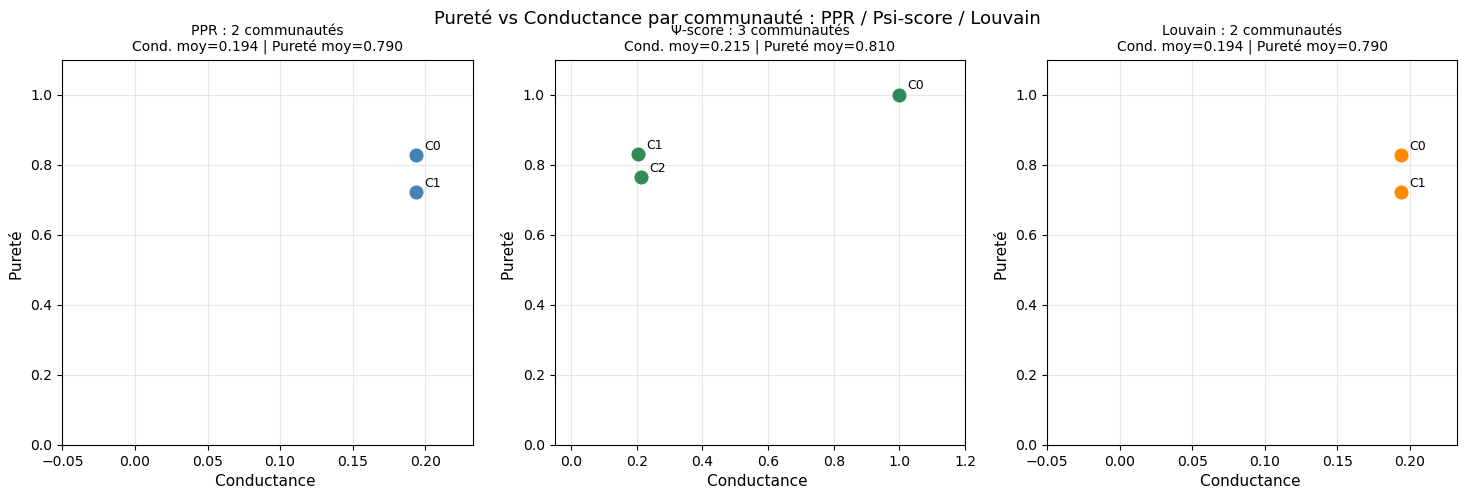

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (communities_ppr,     res_ppr,     'PPR',     'steelblue'),
    (communities_psi,     res_psi,     'Ψ-score',  'seagreen'),
    (communities_louvain, res_lou,     'Louvain',  'darkorange'),
]

for ax, (communities, res, name, color) in zip(axes, configs):
    conds = [conductance(subgraph, c) for c in communities]
    purs  = [purity(
                np.array([true_labels[n] for n in c]),
                np.zeros(len(c), dtype=int)  # chaque cluster = 1 seul label majoritaire
             ) for c in communities]
    
    # Pureté par communauté = fraction du label majoritaire
    purs = []
    for c in communities:
        labels_c = true_labels[list(c)]
        most_common = Counter(labels_c).most_common(1)[0][1]
        purs.append(most_common / len(c))

    ax.scatter(conds, purs, color=color, s=120, zorder=5,
               edgecolors='white', linewidths=0.8)
    
    for i, (cx, cy) in enumerate(zip(conds, purs)):
        ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                    xytext=(6, 4), fontsize=9)

    ax.set_xlabel("Conductance ", fontsize=11)
    ax.set_ylabel("Pureté ", fontsize=11)
    ax.set_title(f"{name} : {len(list(communities))} communautés\n"
                 f"Cond. moy={res['Conductance faible']:.3f} | Pureté moy={res['Pureté']:.3f}",
                 fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.05, max(conds) * 1.2)
    ax.set_ylim(0, 1.1)

plt.suptitle("Pureté vs Conductance par communauté : PPR / Psi-score / Louvain", fontsize=13)
plt.show()

### 9.6 Nombre de noeuds en commun dans les communautés avec les 3 algos

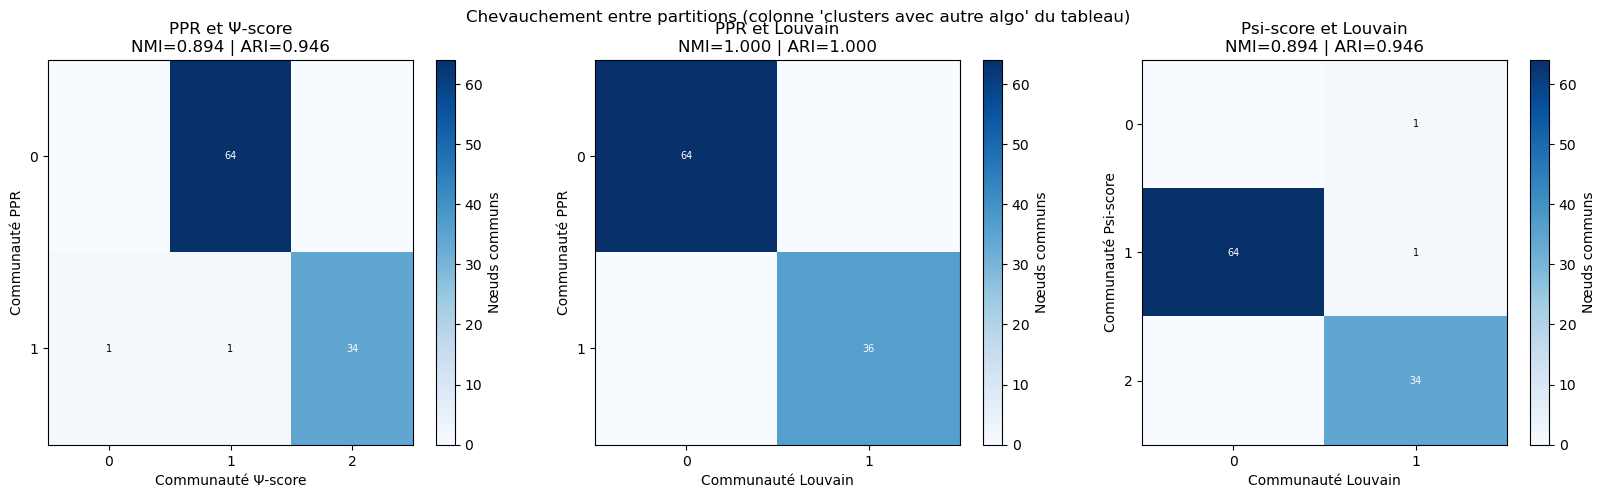

In [39]:
def overlap_matrix(comms_A, comms_B):
    mat = np.zeros((len(comms_A), len(comms_B)), dtype=int)
    for i, ca in enumerate(comms_A):
        for j, cb in enumerate(comms_B):
            mat[i, j] = len(set(ca) & set(cb))
    return mat

pairs = [
    (communities_ppr, communities_psi,     "PPR",     "Ψ-score"),
    (communities_ppr, communities_louvain, "PPR",     "Louvain"),
    (communities_psi, communities_louvain, "Psi-score", "Louvain"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (cA, cB, nameA, nameB) in zip(axes, pairs):
    mat = overlap_matrix(cA, cB)
    nmi_c = normalized_mutual_info_score(
        to_labels(cA, N), to_labels(list(cB), N))
    ari_c = adjusted_rand_score(
        to_labels(cA, N), to_labels(list(cB), N))

    im = ax.imshow(mat, aspect='auto', cmap='Blues')
    plt.colorbar(im, ax=ax, label='Nœuds communs')
    ax.set_xlabel(f"Communauté {nameB}")
    ax.set_ylabel(f"Communauté {nameA}")
    ax.set_title(f"{nameA} et {nameB}\nNMI={nmi_c:.3f} | ARI={ari_c:.3f}")
    ax.set_xticks(range(mat.shape[1]))
    ax.set_yticks(range(mat.shape[0]))
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if mat[i, j] > 0:
                ax.text(j, i, str(mat[i, j]), ha='center', va='center', fontsize=7,
                        color='white' if mat[i, j] > mat.max() * 0.5 else 'black')

plt.suptitle("Chevauchement entre partitions (colonne 'clusters avec autre algo' du tableau)",
             fontsize=12)
plt.show()

## 11. Synthèse

### Récapitulatif des résultats précédents 

In [40]:
print("""
Hypothèses attendues :
  • Modularité Q  : Louvain > PPR = Psi-score  (Louvain maximise Q directement)
  • NMI    : Psi-score > PPR > Louvain  (Psi-score capture mieux les flux tweets/retweets)
  • Conductance   : Louvain <= PPR = Psi-score  (corrélée à Q)
""")


Hypothèses attendues :
  • Modularité Q  : Louvain > PPR = Psi-score  (Louvain maximise Q directement)
  • NMI    : Psi-score > PPR > Louvain  (Psi-score capture mieux les flux tweets/retweets)
  • Conductance   : Louvain <= PPR = Psi-score  (corrélée à Q)

